# CO2 Estimator — Model Training

Trains a regression network to estimate CO2 impact from activity logs.
Factors in time-of-day, day-of-week, month, and peak/off-peak grid load on top of base emission factors.

**Output:** `ecolums_co2_model.tflite` → `app/src/main/assets/`

In [1]:
import subprocess, sys
PY39 = "/Library/Developer/CommandLineTools/usr/bin/python3.9"
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "numpy", "pandas", "matplotlib", "scikit-learn"])
subprocess.check_call([PY39, "-m", "pip", "install", "-q",
    "tensorflow", "numpy", "pandas"])
print("ready")

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


ready


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3.9 -m pip install --upgrade pip' command.


In [2]:
import sys, os, json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Dataset

Synthetic activity logs with EPA 2024 / IPCC AR6 base emission factors.
Contextual multipliers applied for grid load (energy) and passenger occupancy (bus/train).

In [3]:
BASE_FACTORS = {
    0:  0.08,   # BUS    kg CO2 saved vs car / km
    1:  0.21,   # BIKE
    2: -0.21,   # CAR    kg CO2 emitted / km
    3:  0.00,   # WALK
    4:  0.05,   # TRAIN
    5:  0.45,   # ENERGY kg CO2 saved / kWh
    6: -0.50,   # LANDFILL kg CO2 emitted / kg
    7:  0.30,   # RECYCLE
    8:  0.10,   # COMPOST
}
TYPE_NAMES = ["BUS","BIKE","CAR","WALK","TRAIN","ENERGY","LANDFILL","RECYCLE","COMPOST"]

def contextual_multiplier(sub_type, hour, month, dow):
    m = 1.0
    if sub_type == 5:
        if hour in [7, 8, 9, 17, 18, 19, 20]: m *= 1.20
        elif hour in [23, 0, 1, 2, 3, 4]:     m *= 0.82
        if month in [6, 7, 8]:    m *= 1.12
        elif month in [12, 1, 2]: m *= 1.08
    elif sub_type in [0, 4]:
        if hour in [8, 9, 17, 18]: m *= 1.15
    return m

np.random.seed(5)
rows = []
for _ in range(6000):
    t = np.random.choice(9)
    if t <= 4:   q = np.clip(np.random.exponential(8.0),  0.5, 80.0)
    elif t == 5: q = np.clip(np.random.exponential(5.0),  0.1, 50.0)
    else:        q = np.clip(np.random.exponential(1.5),  0.1, 20.0)
    h  = np.random.randint(0, 24)
    dw = np.random.randint(0, 7)
    mo = np.random.randint(1, 13)
    wk = 1.0 if dw >= 5 else 0.0
    co2 = BASE_FACTORS[t] * q * contextual_multiplier(t, h, mo, dw)
    co2 += np.random.normal(0, max(abs(co2) * 0.08, 0.003))
    rows.append([float(t), q, float(h), float(dw), float(mo), wk, co2])

df = pd.DataFrame(rows, columns=["sub_type","quantity","hour_of_day","day_of_week","month","is_weekend","co2_kg"])
df.to_csv("synthetic_data.csv", index=False)
print(f"{len(df)} samples")
df.describe().round(3)

6000 samples


,sub_type,quantity,hour_of_day,day_of_week,month,is_weekend,co2_kg
count,6000.000,6000.000,6000.000,6000.000,6000.000,6000.000,6000.000
mean,3.990,5.415,11.470,3.023,6.488,0.290,0.384
std,2.588,6.719,6.924,2.002,3.426,0.454,1.671
min,0.000,0.100,0.000,0.000,1.000,0.000,-13.350
25%,2.000,1.019,6.000,1.000,4.000,0.000,-0.002
50%,4.000,2.844,11.000,3.000,6.000,0.000,0.152
75%,6.000,7.348,17.000,5.000,9.000,1.000,0.675
max,8.000,77.691,23.000,6.000,12.000,1.000,29.813


## Data Overview

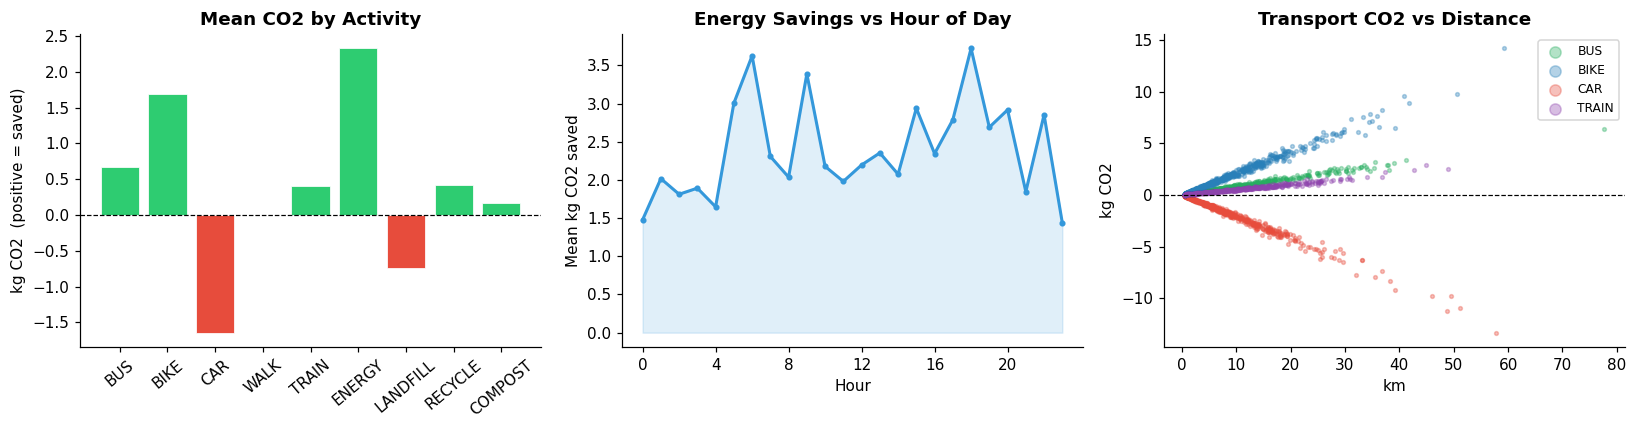

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

means  = [df[df.sub_type == i].co2_kg.mean() for i in range(9)]
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in means]
axes[0].bar(TYPE_NAMES, means, color=colors, edgecolor="white", linewidth=0.5)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Mean CO2 by Activity", fontweight="bold")
axes[0].set_ylabel("kg CO2  (positive = saved)")
axes[0].tick_params(axis="x", rotation=40)

energy = df[df.sub_type == 5]
hourly = energy.groupby("hour_of_day")["co2_kg"].mean()
axes[1].plot(hourly.index, hourly.values, color="#3498db", linewidth=2, marker="o", markersize=3)
axes[1].fill_between(hourly.index, hourly.values, alpha=0.15, color="#3498db")
axes[1].set_title("Energy Savings vs Hour of Day", fontweight="bold")
axes[1].set_xlabel("Hour"); axes[1].set_ylabel("Mean kg CO2 saved")
axes[1].set_xticks(range(0, 24, 4))

tc = {0:"#27ae60", 1:"#2980b9", 2:"#e74c3c", 4:"#8e44ad"}
for t, name in [(0,"BUS"),(1,"BIKE"),(2,"CAR"),(4,"TRAIN")]:
    sub = df[df.sub_type == t]
    axes[2].scatter(sub.quantity, sub.co2_kg, s=6, alpha=0.35, color=tc[t], label=name)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Transport CO2 vs Distance", fontweight="bold")
axes[2].set_xlabel("km"); axes[2].set_ylabel("kg CO2")
axes[2].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig("data_overview.png", bbox_inches="tight")
plt.show()

## Train (Python 3.9 subprocess)

In [5]:
import subprocess, os, textwrap
PY39 = "/Library/Developer/CommandLineTools/usr/bin/python3.9"
code = textwrap.dedent(r'''
import os, sys, shutil, json
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import numpy as np, pandas as pd, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

print(f"TF {tf.__version__}  Python {sys.version.split()[0]}")

df = pd.read_csv("synthetic_data.csv")
X = df[["sub_type","quantity","hour_of_day","day_of_week","month","is_weekend"]].values.astype("float32")
y = df["co2_kg"].values.astype("float32")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train={len(X_train)}  val={len(X_val)}")

normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    normalizer,
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1),
], name="co2_estimator")
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model.summary()

history = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=1)
print(f"stopped at epoch {len(history.history['loss'])}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history.history["loss"]) + 1)
ax1.plot(ep, history.history["loss"],     label="train", color="#3498db", linewidth=2)
ax1.plot(ep, history.history["val_loss"], label="val",   color="#e67e22", linewidth=2, linestyle="--")
ax1.set_title("Loss (MSE)"); ax1.set_yscale("log"); ax1.legend()
ax2.plot(ep, history.history["mae"],     label="train MAE", color="#3498db", linewidth=2)
ax2.plot(ep, history.history["val_mae"], label="val MAE",   color="#e67e22", linewidth=2, linestyle="--")
ax2.set_title("Mean Absolute Error (kg CO2)"); ax2.legend()
plt.tight_layout(); plt.savefig("loss_curves.png", bbox_inches="tight"); plt.close()

y_pred = model.predict(X_val, verbose=0).flatten()
mae  = float(np.mean(np.abs(y_pred - y_val)))
rmse = float(np.sqrt(np.mean((y_pred - y_val)**2)))
r2   = float(1 - np.sum((y_val - y_pred)**2) / np.sum((y_val - np.mean(y_val))**2))
print(f"MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
lim = max(np.abs(y_val).max(), np.abs(y_pred).max()) * 1.05
ax1.scatter(y_val, y_pred, s=8, alpha=0.35, color="#3498db")
ax1.plot([-lim,lim],[-lim,lim],"r--",linewidth=1.5,label="perfect")
ax1.set_xlim(-lim,lim); ax1.set_ylim(-lim,lim)
ax1.set_xlabel("actual kg CO2"); ax1.set_ylabel("predicted kg CO2")
ax1.set_title(f"R2={r2:.3f}"); ax1.legend()
residuals = y_pred - y_val
ax2.hist(residuals, bins=50, color="#3498db", edgecolor="white", linewidth=0.3)
ax2.axvline(0, color="red", linewidth=1.5, linestyle="--")
ax2.set_xlabel("residual kg"); ax2.set_title(f"MAE={mae:.4f} kg")
plt.tight_layout(); plt.savefig("evaluation.png", bbox_inches="tight"); plt.close()

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = converter.convert()
open("ecolums_co2_model.tflite", "wb").write(tflite_bytes)
print(f"model: {os.path.getsize('ecolums_co2_model.tflite') / 1024:.1f} KB")

ASSETS = "../../app/src/main/assets"
os.makedirs(ASSETS, exist_ok=True)
shutil.copy("ecolums_co2_model.tflite", os.path.join(ASSETS, "ecolums_co2_model.tflite"))
print(f"copied to {ASSETS}/")

json.dump({"mae": mae, "rmse": rmse, "r2": r2, "epochs": len(history.history["loss"])},
          open("metrics.json", "w"))

# quick sanity check
interp = tf.lite.Interpreter(model_path="ecolums_co2_model.tflite")
interp.allocate_tensors()
inp = interp.get_input_details()[0]["index"]
out = interp.get_output_details()[0]["index"]
cases = [
    ("bike  5km  8am",   [1, 5.0,  8, 0, 3, 0],  0.21*5),
    ("car   10km 9am",   [2, 10.0, 9, 1, 4, 0], -0.21*10),
    ("energy 3kWh 7pm",  [5, 3.0, 19, 2, 7, 0],  0.45*3),
    ("energy 3kWh 2am",  [5, 3.0,  2, 3, 7, 0],  0.45*3),
    ("recycle 2kg",      [7, 2.0, 12, 4, 3, 0],  0.30*2),
]
print(f"\n{'case':<22} {'pred':>8} {'base':>8} {'delta':>8}")
print("-" * 50)
for label, feat, base in cases:
    x = np.array([feat], dtype=np.float32)
    interp.set_tensor(inp, x); interp.invoke()
    pred = float(interp.get_tensor(out)[0][0])
    print(f"{label:<22} {pred:>8.4f} {base:>8.4f} {pred-base:>+8.4f}")
''')
result = subprocess.run([PY39, "-c", code], capture_output=True, text=True, cwd=os.path.abspath("."))
print(result.stdout)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)

TF 2.19.0  Python 3.9.6
train=4800  val=1200
Model: "co2_estimator"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 6)              │            13 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└───────

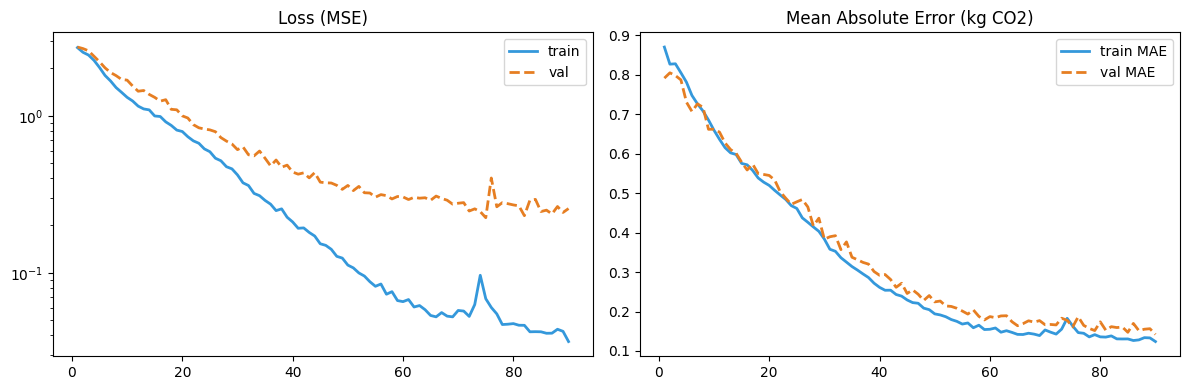

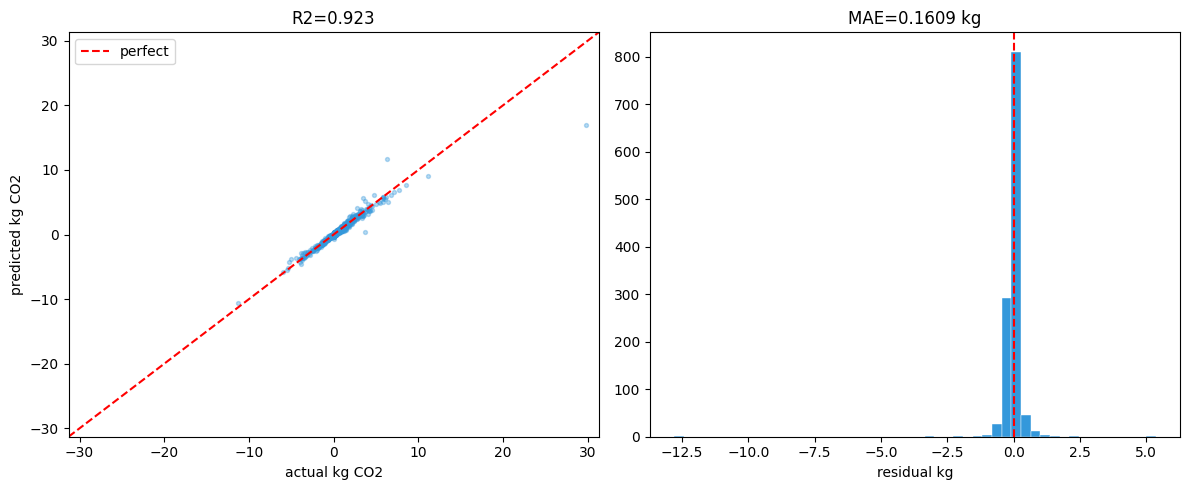

MAE 0.1609 kg  |  R2 0.9227  |  epochs 90


In [6]:
from IPython.display import Image, display
import json, os
for img in ["loss_curves.png", "evaluation.png"]:
    if os.path.exists(img): display(Image(img))
if os.path.exists("metrics.json"):
    m = json.load(open("metrics.json"))
    print(f"MAE {m['mae']:.4f} kg  |  R2 {m['r2']:.4f}  |  epochs {m['epochs']}")